In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("smartwatches.csv")

print("Размер датасета:", df.shape)
display(df.head())

Размер датасета: (450, 16)


,Unnamed: 0,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,NaN,NaN,NaN,NaN,8.0,Yes,NaN,35 - 50 g
1,1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,50 - 75 g
2,2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,NaN,NaN,Silicon,Yes,8.0,Yes,1.7 inches,35 - 50 g
3,3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,75g +
4,4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,NaN,NaN,Other,Yes,8.0,Yes,1.7 inches,35 - 50 g


In [31]:
missing_percent = (df.isna().sum() / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Количество пропусков": df.isna().sum(),
    "Процент пропусков": missing_percent
})

display(missing_table)

,Количество пропусков,Процент пропусков
Unnamed: 0,0,0.00
Brand,0,0.00
Current Price,10,2.22
Original Price,73,16.22
Discount Percentage,73,16.22
Rating,6,1.33
Number OF Ratings,59,13.11
Model Name,35,7.78
Dial Shape,123,27.33
Strap Color,123,27.33


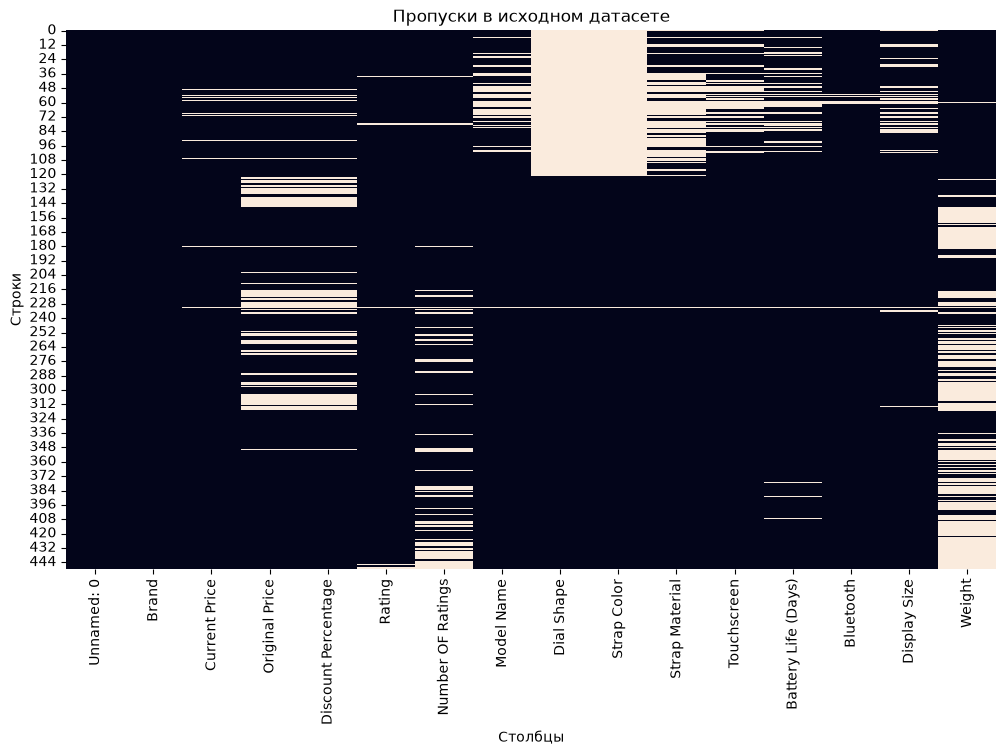

In [32]:
plt.figure(figsize=(12, 7))

sns.heatmap(df.isna(), cbar=False)

plt.title("Пропуски в исходном датасете")
plt.xlabel("Столбцы")
plt.ylabel("Строки")

plt.show()

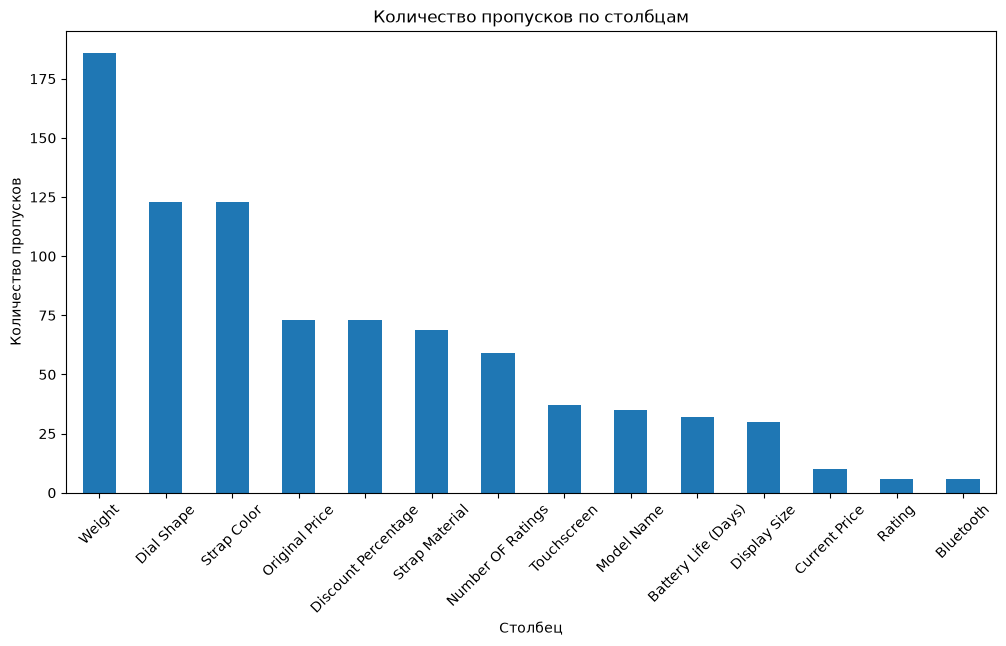

In [33]:
missing = df.isna().sum()

missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))

missing.plot(kind="bar")

plt.title("Количество пропусков по столбцам")
plt.xlabel("Столбец")
plt.ylabel("Количество пропусков")

plt.xticks(rotation=45)
plt.show()

In [34]:
# Доля пропусков в каждом столбце
missing_percent = df.isna().mean() * 100

print("Процент пропусков:")
display(missing_percent.sort_values(ascending=False))

Процент пропусков:


Weight                 41.333333
Dial Shape             27.333333
Strap Color            27.333333
Original Price         16.222222
Discount Percentage    16.222222
Strap Material         15.333333
Number OF Ratings      13.111111
Touchscreen             8.222222
Model Name              7.777778
Battery Life (Days)     7.111111
Display Size            6.666667
Current Price           2.222222
Rating                  1.333333
Bluetooth               1.333333
Brand                   0.000000
Unnamed: 0              0.000000
dtype: float64

In [35]:
threshold = 40

columns_to_drop = missing_percent[missing_percent > threshold].index

print("Столбцы для удаления:")
print(list(columns_to_drop))

df = df.drop(columns=columns_to_drop)

print("Размер датасета после удаления столбцов:", df.shape)

Столбцы для удаления:
['Weight']
Размер датасета после удаления столбцов: (450, 15)


In [36]:
max_missing = 7

rows_before = len(df)

df = df[df.isna().sum(axis=1) <= max_missing]

rows_after = len(df)

deleted_rows = rows_before - rows_after

print("Удалено строк:", deleted_rows)
print("Осталось строк:", rows_after)

Удалено строк: 9
Осталось строк: 441


In [37]:
print("Пропуски после удаления:")
display(df.isna().sum())
print("Итоговый размер после задания 2:", df.shape)

Пропуски после удаления:


Unnamed: 0               0
Brand                    0
Current Price            7
Original Price          70
Discount Percentage     70
Rating                   4
Number OF Ratings       57
Model Name              27
Dial Shape             114
Strap Color            114
Strap Material          60
Touchscreen             28
Battery Life (Days)     24
Bluetooth                0
Display Size            22
dtype: int64

Итоговый размер после задания 2: (441, 15)


In [38]:
df_processed = df.copy()
knn_columns = [
    "Current Price",
    "Original Price",
    "Battery Life (Days)"
]

median_columns = [
    "Discount Percentage",
    "Rating",
    "Number OF Ratings"
]

In [40]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

df_processed[knn_columns] = knn_imputer.fit_transform(
    df_processed[knn_columns]
)

In [41]:
for column in median_columns:
    df_processed[column] = df_processed[column].fillna(
        df_processed[column].median()
    )

In [42]:
categorical_columns = df_processed.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    df_processed[column] = df_processed[column].fillna("Unknown")

/tmp/ipykernel_84746/2044271828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_processed.select_dtypes(


In [43]:
print("Общее количество пропусков:",
      df_processed.isna().sum().sum())

Общее количество пропусков: 0


In [45]:
df_original = pd.read_csv("smartwatches.csv")

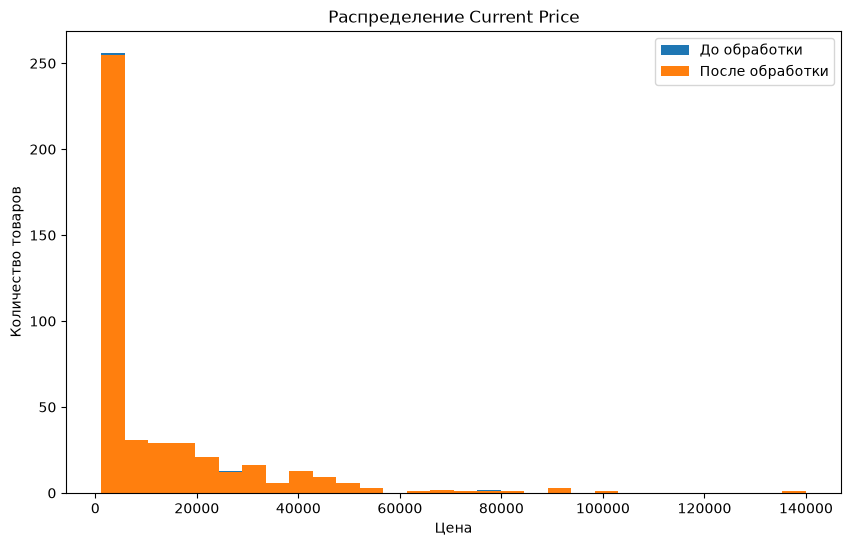

In [48]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_original["Current Price"].dropna(),
    bins=30,
    label="До обработки"
)

plt.hist(
    df_processed["Current Price"],
    bins=30,
    label="После обработки"
)

plt.title("Распределение Current Price")
plt.xlabel("Цена")
plt.ylabel("Количество товаров")
plt.legend()

plt.show()

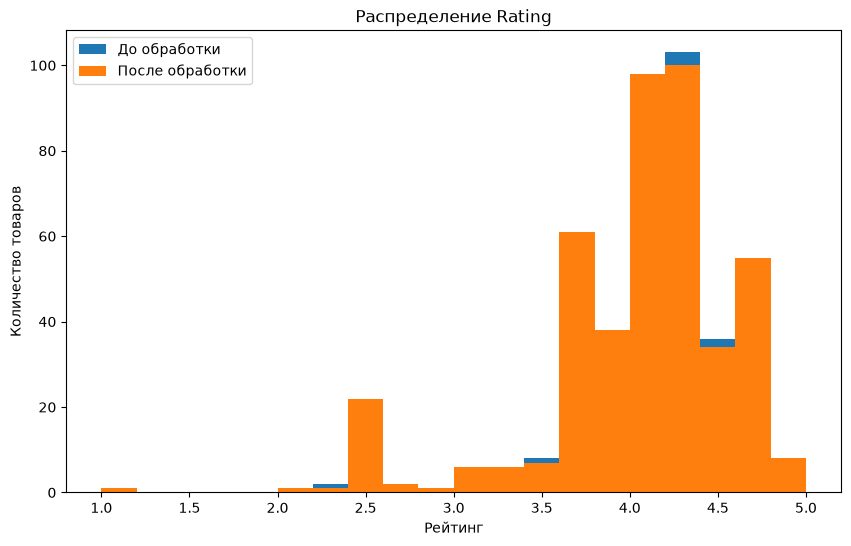

In [50]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_original["Rating"].dropna(),
    bins=20,
    label="До обработки"
)

plt.hist(
    df_processed["Rating"],
    bins=20,
    label="После обработки"
)

plt.title("Распределение Rating")
plt.xlabel("Рейтинг")
plt.ylabel("Количество товаров")
plt.legend()

plt.show()

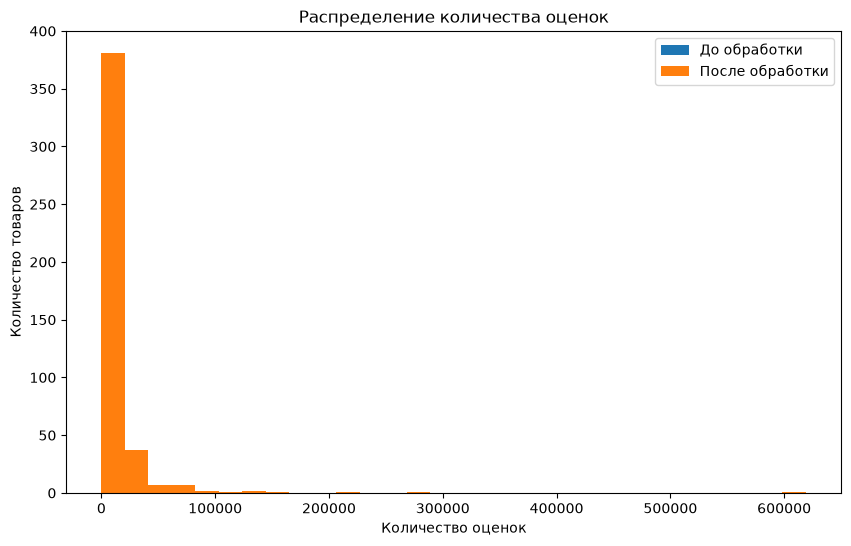

In [52]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_original["Number OF Ratings"].dropna(),
    bins=30,
    label="До обработки"
)

plt.hist(
    df_processed["Number OF Ratings"],
    bins=30,
    label="После обработки"
)

plt.title("Распределение количества оценок")
plt.xlabel("Количество оценок")
plt.ylabel("Количество товаров")
plt.legend()

plt.show()

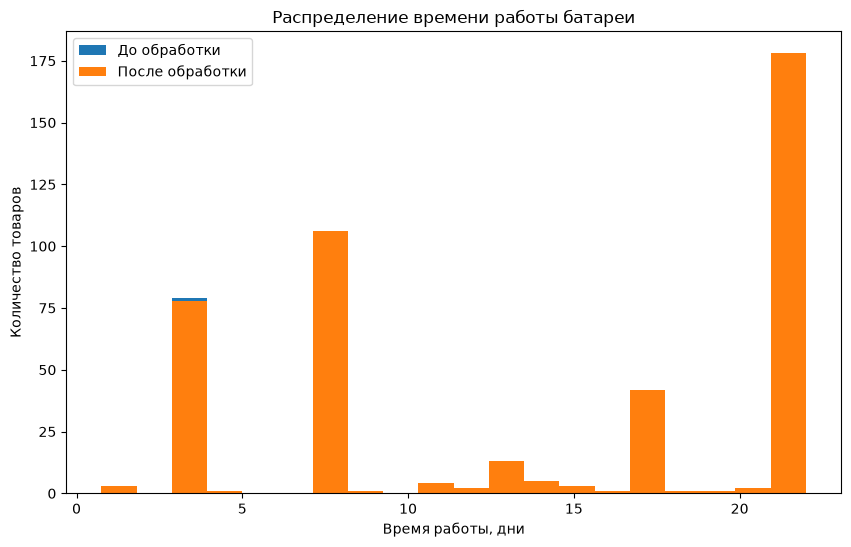

In [53]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_original["Battery Life (Days)"].dropna(),
    bins=20,
    label="До обработки"
)

plt.hist(
    df_processed["Battery Life (Days)"],
    bins=20,
    label="После обработки"
)

plt.title("Распределение времени работы батареи")
plt.xlabel("Время работы, дни")
plt.ylabel("Количество товаров")
plt.legend()

plt.show()